In [1]:
import pandas as pd
import numpy as np

#graphs 
import seaborn as sns
import matplotlib.pyplot as plt 

#stats 
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

#timeseries 

from mlforecast import MLForecast

# Funções

In [57]:
class EdaTimeSeries():
    def __init__(self, ts: pd.DataFrame):
        self.ts = ts
    def univariate_hist_box(self):
        fig, axs = plt.subplots(2,2, figsize=(12,8))
        axs = axs.flatten()
        
        u = self.ts['y'].mean()
        md = self.ts['y'].median()
        
        sns.histplot(data=self.ts, x='y', ax=axs[0])
        axs[0].set_title('Histograma da Receita Diária')
        axs[0].axvline(x=u, color='dimgray', linestyle="--", label='media')
        axs[0].axvline(x=md, color='black', linestyle="--", label='mediana')
        axs[0].legend()
        
        sns.kdeplot(data=self.ts, x='y', ax=axs[1])
        axs[1].set_title('Densidade')
        axs[1].axvline(x=u, color='dimgray', linestyle="--", label='media')
        axs[1].axvline(x=md, color='black', linestyle="--", label='mediana')
        axs[1].legend()
        
        sns.boxplot(data=self.ts, x='y', ax=axs[2])
        axs[2].set_title('Boxplot')
        
        sns.scatterplot(data=self.ts, x=self.ts.index, y='y', ax=axs[3])
        axs[3].set_title('Dispersao')
        
        fig.tight_layout()
        plt.show()
    
    def line_over_period(self, period, hue=None):
        fig, ax = plt.subplots(figsize=(10,4))
        if hue is None: 
            sns.lineplot(data=self.ts, x=period, y='y', ax=ax)
        else: 
            sns.lineplot(data=self.ts, x=period, y='y', hue=hue, ax=ax)
        ax.set_title(f'Receita por {period}')
        ax.set_xlabel(f'{period}')
        ax.set_xticks(ax.get_xticks()[::3])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
        plt.tight_layout()
        plt.show()
        

In [3]:
#funcoes transformacao data 

def year_month(dates):
    return dates.strftime("%Y-%m")

# Import File

In [38]:
df = pd.read_parquet("data/silver/sales_per_region.parquet")

In [39]:
df.head(3)

,numero_do_pedido,data,status_pagamento,estado,total
0,12309,2025-06-16,Confirmado,São Paulo,101.79
1,12308,2025-06-15,Confirmado,São Paulo,187.26
2,12307,2025-06-15,Confirmado,Paraná,119.01


In [40]:
df = df.loc[df['data'] < "2025-06-01", :].reset_index(drop=True)

# EDA

## Agregação de Dados por Dia

In [42]:
ts = df.groupby("data")["total"].sum().reset_index()
ts.columns = ["ds", "y"]
ts.head(3)

,ds,y
0,2022-04-18,339.75
1,2022-04-19,99.60
2,2022-04-20,58.38


## Criação de Features de Data

In [43]:
ts.insert(0, 'unique_id', 'ecommerce-sale')

preprocess = MLForecast(
    models=[],
    freq=['D'],
    date_features=['day', 'year', 'month', 'weekday', year_month]
)

ts = preprocess.preprocess(ts)

## Descritiva

In [44]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   unique_id   1128 non-null   object        
 1   ds          1128 non-null   datetime64[ns]
 2   y           1128 non-null   float64       
 3   day         1128 non-null   uint8         
 4   year        1128 non-null   uint16        
 5   month       1128 non-null   uint8         
 6   weekday     1128 non-null   uint8         
 7   year_month  1128 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2), uint16(1), uint8(3)
memory usage: 40.9+ KB


In [45]:
ts[['ds', 'y']].describe().T

,count,mean,min,25%,50%,75%,max,std
ds,1128,2023-11-12 04:47:14.042553344,2022-04-18 00:00:00,2023-02-01 06:00:00,2023-11-14 12:00:00,2024-08-22 06:00:00,2025-05-31 00:00:00,NaN
y,1128.0,1231.022686,20.85,633.1825,1091.21,1655.31,13543.14,901.732035


- Temos um pouco mais do que 3 anos de dados
- Média e mediana, a princípio, não muito distante uma da outra.
- O máximo valor bem acima do nosso percentil 75.

## Analise de Distribuição da Receita

In [46]:
eda = EdaTimeSeries(ts=ts)

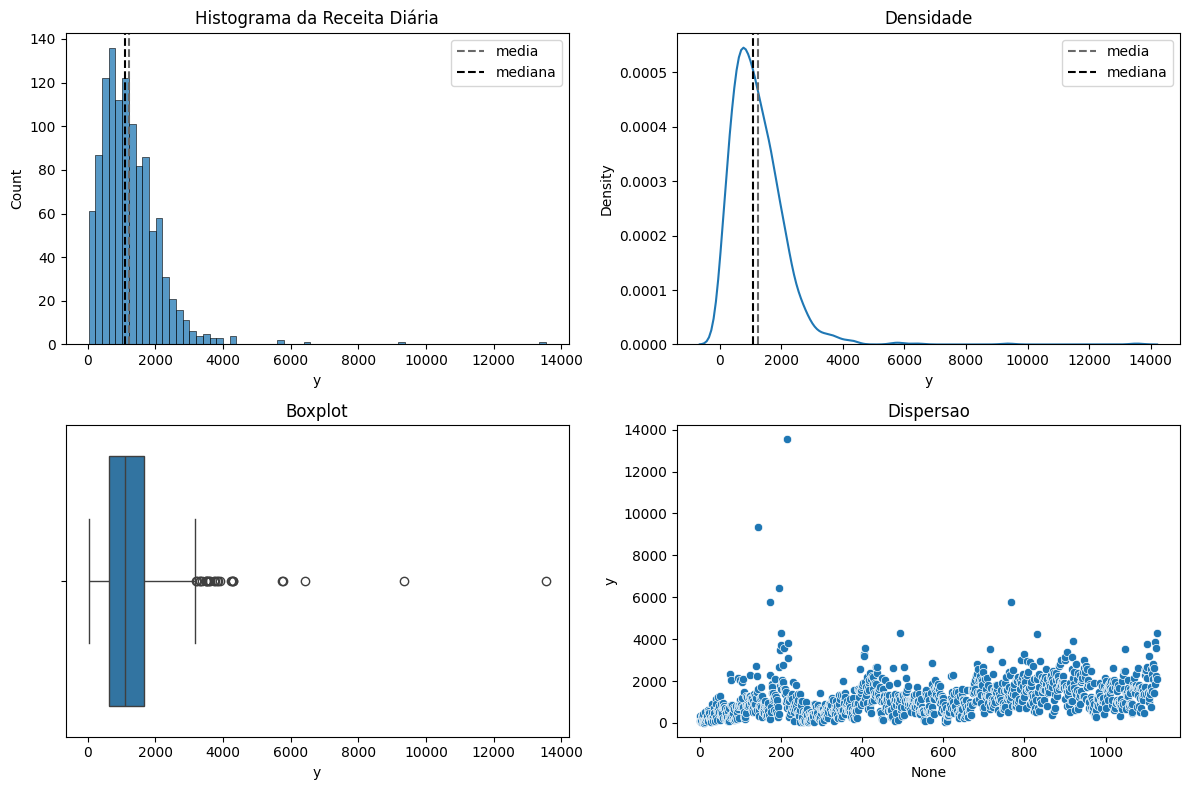

In [47]:
eda.univariate_hist_box()

In [48]:
print(f"Curtose dos dados: {stats.kurtosis(ts['y'])}")
print(f"Assimetria nos dados de: {stats.skew(ts['y'])}")

Curtose dos dados: 37.705574278413096
Assimetria nos dados de: 3.7679845226988857


- Percebe-se que temos alguns outliers que são bem acima, destoando dos demais valores encontrados
- Isso fica evidente no dado de assimetria, que está a direita (positivo). Onde em sua maior parte os dados estão concentrados em valores mais baixos, porém os valores mais altos acaba puxando a distribuição
- Uma transformação nos dados vai ser importante para conseguirmos estabilizar a variância

## Análise de Outliers

- Utilizaremos o método de IQR para identificarmos os outliers e consequentemente validar se existe algum padrão entre eles.

In [49]:
q3 = ts['y'].quantile(.75)
q1 = ts['y'].quantile(.25)
abo = q3 + (1.5*(q3-q1))

ts_outlier = ts.loc[ts['y'] > abo, :]
ts_outlier.head(3)

,unique_id,ds,y,day,year,month,weekday,year_month
144,ecommerce-sale,2022-09-14,9353.15,14,2022,9,2,2022-09
173,ecommerce-sale,2022-10-13,5754.12,13,2022,10,3,2022-10
195,ecommerce-sale,2022-11-04,6422.40,4,2022,11,4,2022-11


In [50]:
qtd_outlier = len(ts_outlier)
total_data = len(ts)

print(f"Quantidade de outliers: {qtd_outlier}")
print(f"Percentual de outliers: {qtd_outlier/total_data:.2f}")

Quantidade de outliers: 25
Percentual de outliers: 0.02


- Temos um total de 2,00% de outlier em todo nosso dado

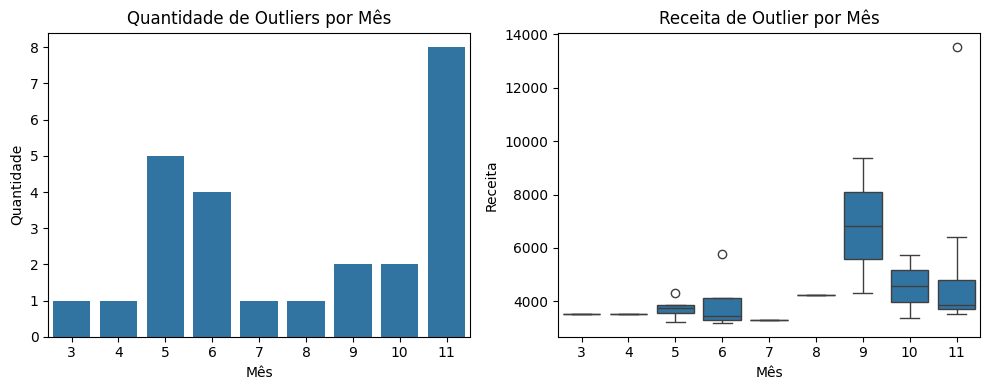

In [51]:
qtd_outlier_mes = ts_outlier['month'].value_counts().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax = ax.flatten()

sns.barplot(data=qtd_outlier_mes, x='month', y='count', ax=ax[0])
ax[0].set_title('Quantidade de Outliers por Mês')
ax[0].set_ylabel('Quantidade')
ax[0].set_xlabel('Mês')

sns.boxplot(data=ts_outlier, x='month', y='y', ax=ax[1])
ax[1].set_title('Receita de Outlier por Mês')
ax[1].set_ylabel('Receita')
ax[1].set_xlabel('Mês')

plt.tight_layout()
plt.show()

- Os outliers em sua maioria acontecem no mês de novembro, BlackFriday, que era de se esperar em um e-commerce.
- Posteriormente, vemos os meses de maio e junho como o segundo em resultado.
- Em questão de distribuição de receita, setembro apresenta uma distribuição maior.
- Além disso, dentro do mês de novembro, que é a black, não apresentou uma distribuição de receita tão grande quanto setembro, mas tem um ponto de máximo bem considerável na casa dos 14k.

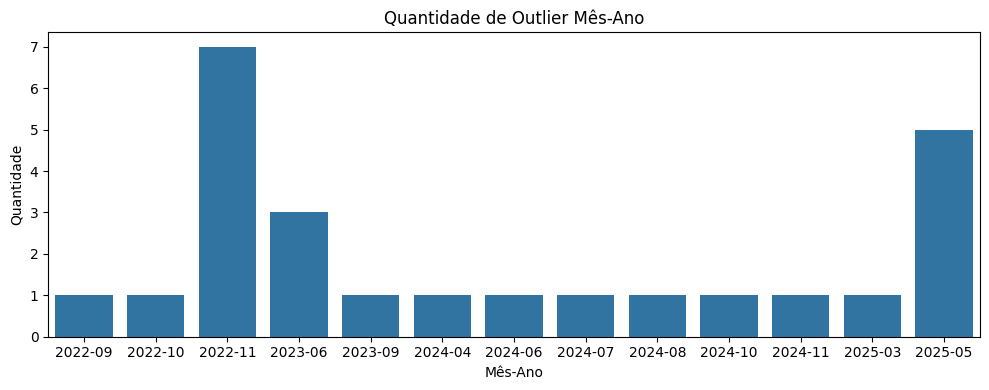

In [52]:
outlier_year_month = ts_outlier['year_month'].value_counts().reset_index()
outlier_year_month = outlier_year_month.sort_values('year_month')

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=outlier_year_month, x='year_month', y='count', ax=ax)
ax.set_title('Quantidade de Outlier Mês-Ano')
ax.set_ylabel('Quantidade')
ax.set_xlabel('Mês-Ano')

plt.tight_layout()
plt.show()


- A quantidade de outlier expressiva que aconteceu na Black de 2022 não se repetiu na Black de 2023 e nem 2024. A quantidade de outliers, basicamente está diminuindo e quando acontece temos uma ocorrência dentro do mês.

## Análise da Receita por Dia

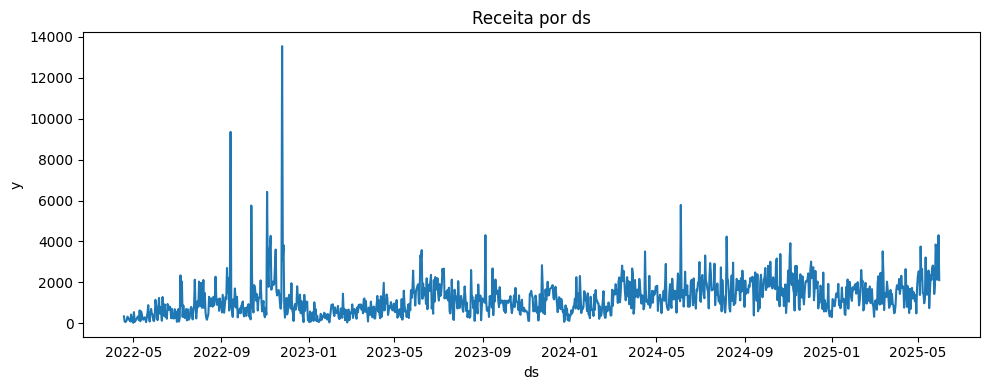

In [53]:
eda.line_over_period(period='ds')

- A princípio, não temos uma tendência clara nos dados de crescimento. Tem alguns destaques para os dados que são outliers.
- Para continuarmos as análises e testes estatísticos, vamos buscar transformar os dados para diminuir o efeito dos outliers

## Análise Receita por Mês

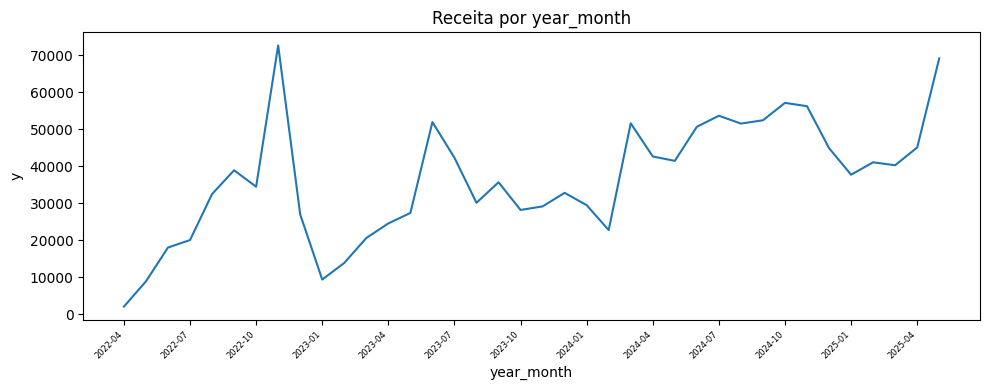

In [67]:
ts_month = ts.groupby(['year_month', 'month', 'year'])['y'].sum().reset_index()
eda_month = EdaTimeSeries(ts=ts_month)
eda_month.line_over_period(period='year_month')


- Analisando mensalmente, com os dados agregados para reduzir a variância, percebe-se um claro crescimento de abril até novembro. Depois uma queda. Novamente tivemos uma escalada até o mês 6 em 2023 e queda seguida de um platô na receita. Em 2024 começou o ano em baixa e novamente melhoramos os resultados, porém em janeiro de 2025 tivemos novamente uma queda.

- Aparentemente, quando temos um pico, sempre vem um momento de baixa

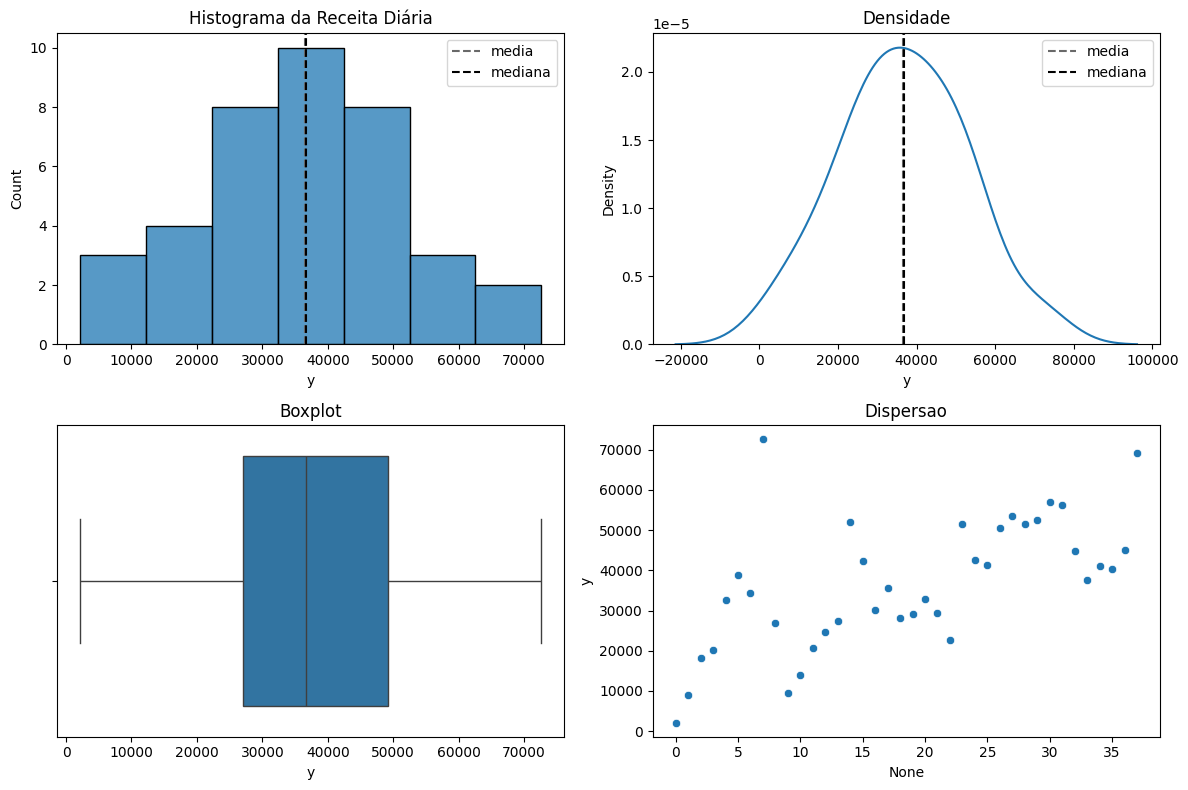

In [68]:
eda_month.univariate_hist_box()

- Sendo a receita mensal, percebe-se que os dados se aproximam bem de uma curva normal, tanto que a média e mediana estão plotadas uma sobre a outra

In [69]:
mu = ts_month['y'].mean()
md = ts_month['y'].median()

print(f'Valor da média é: {mu} e mediana de {md}')

Valor da média é: 36541.93657894737 e mediana de 36700.16499999999


In [70]:
stats.skew(ts_month['y'])

np.float64(0.03998202244178941)

- Pela métrica temos um dado quase simétrico